### Process Bicimad Files

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import shape
import ast
from pathlib import Path

In [2]:
def process_mad_df(path):
    raw_df = pd.read_csv(path, sep=';')
    df = raw_df[(~raw_df["geolocation_unlock"].isna()) & (~raw_df["geolocation_unlock"].isna())]
    df['geolocation_unlock'] = df['geolocation_unlock'].apply(ast.literal_eval)
    df['geolocation_lock'] = df['geolocation_lock'].apply(ast.literal_eval)
    df['geom_unlock'] = df['geolocation_unlock'].apply(shape)
    df['geom_lock'] = df['geolocation_lock'].apply(shape)
    gdf = gpd.GeoDataFrame(df, geometry='geom_lock', crs="EPSG:4326")
    return gdf

In [4]:
folder_path = Path("bicimad_data")  

all_gdfs = []

for file_path in folder_path.glob("*.csv"):  
    gdf = process_mad_df(file_path)
    all_gdfs.append(gdf)

/tmp/ipykernel_1517479/1285981.py:2: DtypeWarning: Columns (0: station_unlock) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(path, sep=';')


KeyboardInterrupt: 

In [ ]:
combined_gdf = gpd.GeoDataFrame(pd.concat(all_gdfs, ignore_index=True), crs="EPSG:4326", geometry="geom_lock")
combined_gdf

,fecha,idBike,fleet,trip_minutes,geolocation_unlock,address_unlock,unlock_date,locktype,unlocktype,geolocation_lock,...,lock_date,station_unlock,dock_unlock,unlock_station_name,station_lock,dock_lock,lock_station_name,geom_unlock,geom_lock,idTrip
0,2022-02-01,5687.0,1.0,5.03,"{'type': 'Point', 'coordinates': [-3.7007111, ...",NaN,2022-02-01T00:00:01,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.7036825, ...",...,2022-02-01T00:05:03,57.0,10.0,Plaza de Lavapiés,38.0,21.0,Jacinto Benavente,POINT (-3.7007111 40.4083061),POINT (-3.70368 40.41468),NaN
1,2022-02-01,4773.0,1.0,11.18,"{'type': 'Point', 'coordinates': [-3.6787441, ...",NaN,2022-02-01T00:00:08,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.65779, 40...",...,2022-02-01T00:11:19,96.0,11.0,Príncipe de Vergara,226.0,3.0,Camino Vinateros,POINT (-3.6787441 40.426134),POINT (-3.65779 40.41053),NaN
2,2022-02-01,659.0,1.0,7.18,"{'type': 'Point', 'coordinates': [-3.6933498, ...",NaN,2022-02-01T00:00:16,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.68745, 40...",...,2022-02-01T00:07:27,91.0,17.0,Cibeles,110.0,10.0,Serrano,POINT (-3.6933498 40.4186516),POINT (-3.68745 40.42699),NaN
3,2022-02-01,7249.0,1.0,22.03,"{'type': 'Point', 'coordinates': [-3.648958444...",NaN,2022-02-01T00:00:17,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6959166, ...",...,2022-02-01T00:22:19,238.0,24.0,Carlota O’Neill,176.0,20.0,Batalla del Salado,POINT (-3.648958444298144 40.44370542379883),POINT (-3.69592 40.40447),NaN
4,2022-02-01,4353.0,1.0,10.25,"{'type': 'Point', 'coordinates': [-3.6758383, ...",NaN,2022-02-01T00:00:26,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.697895, 4...",...,2022-02-01T00:10:41,103.0,1.0,Plaza de Felipe II,62.0,14.0,Augusto Figueroa,POINT (-3.6758383 40.4239447),POINT (-3.6979 40.42229),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4144129,2022-10-31,7484.0,1.0,4.80,"{'type': 'Point', 'coordinates': [-3.6983888, ...",'Calle Embajadores nº 101',2022-10-31T23:59:13,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6941944, ...",...,2022-11-01T00:04:01,179.0,20.0,171 - Embajadores-Cáceres,185.0,12.0,177 - Legazpi,POINT (-3.6983888 40.39975),POINT (-3.69419 40.39147),NaN
4144130,2022-10-31,7310.0,1.0,4.37,"{'type': 'Point', 'coordinates': [-3.6983888, ...",'Calle Embajadores nº 101',2022-10-31T23:59:33,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.6941944, ...",...,2022-11-01T00:03:55,179.0,16.0,171 - Embajadores-Cáceres,185.0,20.0,177 - Legazpi,POINT (-3.6983888 40.39975),POINT (-3.69419 40.39147),NaN
4144131,2022-10-31,7767.0,1.0,6.35,"{'type': 'Point', 'coordinates': [-3.6982353, ...",'Calle José Abascal nº 33',2022-10-31T23:59:44,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.700423, 4...",...,2022-11-01T00:06:05,161.0,13.0,129 - José Abascal,58.0,7.0,54 - Barceló,POINT (-3.6982353 40.4383865),POINT (-3.70042 40.42668),NaN
4144132,2022-10-31,3795.0,1.0,18.10,"{'type': 'Point', 'coordinates': [-3.660776867...",'Camino de Valderribas nº 94',2022-10-31T23:59:53,STATION,STATION,"{'type': 'Point', 'coordinates': [-3.7022591, ...",...,2022-11-01T00:17:59,234.0,10.0,226 - Sierra Toledana,52.0,19.0,48 - Embajadores 2,POINT (-3.6607768678037744 40.39901531507069),POINT (-3.70226 40.40561),NaN


In [4]:
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    'host': 'localhost',
    'dbname': os.getenv("POSTGRES_DB"),
    'user': os.getenv("POSTGRES_USER"),
    'password': os.getenv("POSTGRES_PASSWORD"),
    'port': 5432
}
engine = create_engine(f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@"
                f"{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}")

In [6]:
combined_gdf.to_postgis("bicimad_trips",con=engine, if_exists="replace")

In [5]:
combined_gdf = gpd.GeoDataFrame.from_postgis("SELECT * FROM bicimad_trips",engine, geom_col="geom_lock")

In [7]:
combined_gdf["unlock_station_name"].unique()

<StringArray>
[           'Plaza de Lavapiés',          'Príncipe de Vergara',
                      'Cibeles',              'Carlota O’Neill',
           'Plaza de Felipe II',               'Conde Peñalver',
                      'Serrano',                 'Santa Isabel',
     'Santa María de la Cabeza',                      'Legazpi',
 ...
            '148 - Serrano 210',                   '257 - INEF',
    '209 - Plaza de Castilla 2',                '247 - Zurbano',
               '107 - Columela',            '248 - Torre Cepsa',
 '258 - Ciudad Universitaria 1',      '20a - Banco de España A',
     '116a - Plaza de España A',        '152 - General Perón 1']
Length: 520, dtype: str

### Regression

In [10]:
POIs = gpd.GeoDataFrame.from_postgis("""SELECT * FROM "pois_Madrid" """,engine, geom_col="geometry")
POIs

,osmid,geometry,landuse,building,amenity,leisure,shop,office,sport,tourism,...,School,Health,Leisure,Shops,Services,Industry,Catering_industry,Tourism,Others,Leisure_area
0,6119303,POINT (-3.7608 40.39083),NaN,school,NaN,NaN,NaN,NaN,NaN,NaN,...,2847.296015,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
1,24405304,POINT (-3.75838 40.38479),NaN,retail,NaN,NaN,supermarket,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,2022.586028,0.000000,0.0,0.000000,0.0,0.0,0.000000
2,24467160,POINT (-3.76424 40.38511),NaN,civic,townhall,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,1413.355208,0.000000,1413.355208,0.0,0.000000,0.0,0.0,0.000000
3,24467163,POINT (-3.76398 40.38622),NaN,retail,NaN,NaN,mall,NaN,NaN,NaN,...,0.000000,9172.604168,9172.604168,9172.604168,9172.604168,0.0,917.260417,0.0,0.0,0.000000
4,27566917,POINT (-3.75694 40.38608),NaN,apartments,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,2099.652345,0.0,2099.652345,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103581,4731217,POINT (-3.64033 40.38439),NaN,NaN,NaN,park,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,703702.043670
103582,15021912,POINT (-3.63433 40.38112),NaN,NaN,NaN,park,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,1345.145901
103583,15901217,POINT (-3.62532 40.37424),NaN,NaN,NaN,park,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,16220.352094
103584,940791173,POINT (-3.78372 40.45177),NaN,yes,NaN,NaN,NaN,NaN,climbing,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,13.893621


In [11]:
zones_gdf = gpd.GeoDataFrame.from_postgis("""SELECT * FROM "madrid_grid" """,engine, geom_col="geom", crs=4326).rename(
    columns={"geom": "geometry"})
zones_gdf= zones_gdf.set_geometry(col="geometry")
zones_gdf

,geometry,id,city_center,count_prod,count_attr
0,"POLYGON ((-3.75496 40.3436, -3.75496 40.35729,...",6,No,NaN,NaN
1,"POLYGON ((-3.77292 40.42571, -3.77292 40.43939...",7,No,NaN,NaN
2,"POLYGON ((-3.73699 40.35729, -3.73699 40.37098...",8,No,NaN,NaN
3,"POLYGON ((-3.80886 40.41204, -3.80886 40.42571...",12,No,NaN,NaN
4,"POLYGON ((-3.80886 40.42571, -3.80886 40.43939...",14,No,NaN,NaN
...,...,...,...,...,...
99,"POLYGON ((-3.70106 40.39835, -3.70106 40.41204...",44,Yes,340037.0,345867.0
100,"POLYGON ((-3.68309 40.45306, -3.68309 40.46673...",46,Yes,26566.0,26333.0
101,"POLYGON ((-3.71903 40.41204, -3.71903 40.42571...",49,Yes,442737.0,438429.0
102,"POLYGON ((-3.68309 40.42571, -3.68309 40.43939...",64,Yes,247509.0,241127.0


In [12]:
def aggregate_over_zones(pois_categorized, zones: gpd.GeoDataFrame, zone_id_column:str ='ZONENUMMER'):
    """
    Aggregates POIs data into zonal characteristics representing the number of POIs of each type in each zone.

    Parameters
    ----------
    zones: gpd.GeoDataFrame
    zone_id_column: string

    Returns
    -------
    gdf_zones: zones with aggregated info on POIs as new columns

    """
    # TODO columns in aggregate_over_zones hardcoded
    columns_atr = ['School', 'Health', 'Leisure',
                    'Shops', 'Services', 'Industry', 'Catering_industry', 'Tourism',
                    'Others', 'Leisure_area']
    columns_prod = ['large_residential', 'small_residential']
    columns = columns_prod + columns_atr
    gdf_zones = zones.copy()
    for i in columns:
        gdf_zones[i] = 0.0

    proj_crs = 3857
    
    crs_poi = pois_categorized.crs.to_epsg()
    crs_zones = gdf_zones.crs.to_epsg()
    if crs_poi != crs_zones:
        pois_categorized = pois_categorized.to_crs(proj_crs)
        gdf_zones = gdf_zones.to_crs(proj_crs)

    pois_categorized = gpd.sjoin(pois_categorized, gdf_zones.loc[:, [zone_id_column, "geometry"]], how='inner', predicate='within',
                                    lsuffix='1', rsuffix='2')
    pois_categorized = pois_categorized.astype({zone_id_column: 'int64'})
    pois_categorized = pois_categorized.drop('index_2', axis=1)
    pois_categorized = pois_categorized.sort_values(zone_id_column)
    gdf_group = pois_categorized.groupby(zone_id_column)
    for ind, gr in gdf_group:
        for col in columns:
            gdf_zones.loc[gdf_zones[zone_id_column] == ind, col] = gr[col].sum()

    gdf_zones['total_activity'] = gdf_zones.loc[:, columns_atr].sum(axis=1)
    gdf_zones['total_residential'] = gdf_zones.loc[:, columns_prod].sum(axis=1)
    gdf_zones = gdf_zones.to_crs(crs_zones)
    # self.zones = gdf_zones
    return gdf_zones

In [13]:
new_zones_gdf = aggregate_over_zones(POIs,zones_gdf,zone_id_column='id')
new_zones_gdf

,geometry,id,city_center,count_prod,count_attr,large_residential,small_residential,School,Health,Leisure,Shops,Services,Industry,Catering_industry,Tourism,Others,Leisure_area,total_activity,total_residential
0,"POLYGON ((-3.75496 40.3436, -3.75496 40.35729,...",6,No,NaN,NaN,3.663005e+04,98604.866829,8912.504530,6209.317811,1981.193431,4848.013874,16793.881504,86614.884976,35.995267,0.000000,1330.334067,126905.418274,2.536315e+05,1.352349e+05
1,"POLYGON ((-3.77292 40.42571, -3.77292 40.43939...",7,No,NaN,NaN,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.629930,0.000000,0.000000,0.000000,0.000000,6.162993e+01,0.000000e+00
2,"POLYGON ((-3.73699 40.35729, -3.73699 40.37098...",8,No,NaN,NaN,0.000000e+00,953.081341,3799.829208,0.000000,727.799053,170.626359,7325.429907,9115.233306,0.000000,0.000000,1699.646863,213787.070965,2.366256e+05,9.530813e+02
3,"POLYGON ((-3.80886 40.41204, -3.80886 40.42571...",12,No,NaN,NaN,0.000000e+00,274629.096448,19014.188484,1572.497670,3405.757166,3214.964885,87846.522739,55.077571,3415.287490,4343.497821,0.000000,461462.318509,5.843301e+05,2.746291e+05
4,"POLYGON ((-3.80886 40.42571, -3.80886 40.43939...",14,No,NaN,NaN,1.237330e+04,271486.928505,59984.973313,17967.803126,8500.684643,40066.928892,39288.762388,8206.777885,23080.598622,647.288907,3214.273656,681150.208564,8.821083e+05,2.838602e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,"POLYGON ((-3.70106 40.39835, -3.70106 40.41204...",44,Yes,340037.0,345867.0,9.661322e+05,84311.039531,72028.112097,52184.386654,62226.650446,212064.277631,446848.314879,41842.782557,135298.015780,168635.522732,15805.776539,199753.661352,1.406688e+06,1.050443e+06
100,"POLYGON ((-3.68309 40.45306, -3.68309 40.46673...",46,Yes,26566.0,26333.0,7.657983e+05,19303.218226,42165.959592,47923.682541,13743.435775,39611.496925,109555.143470,9523.323137,35084.144797,29929.005142,22938.074060,232753.738431,5.832280e+05,7.851015e+05
101,"POLYGON ((-3.71903 40.41204, -3.71903 40.42571...",49,Yes,442737.0,438429.0,1.292028e+06,94900.528025,41649.652999,30781.480972,47946.870163,334064.418721,405721.249597,8834.654303,322854.377640,254855.394627,53281.186849,702613.755272,2.202603e+06,1.386928e+06
102,"POLYGON ((-3.68309 40.42571, -3.68309 40.43939...",64,Yes,247509.0,241127.0,1.506027e+06,43850.907939,59940.533854,110624.651141,18351.288822,179654.210603,275514.845805,7793.587547,175323.868042,31425.071157,18780.955086,223328.114114,1.100737e+06,1.549878e+06


In [14]:
analysis_df = new_zones_gdf[new_zones_gdf["count_prod"] > 1000] # Get only segments where there are enough stations
analysis_df

,geometry,id,city_center,count_prod,count_attr,large_residential,small_residential,School,Health,Leisure,Shops,Services,Industry,Catering_industry,Tourism,Others,Leisure_area,total_activity,total_residential
20,"POLYGON ((-3.70106 40.45306, -3.70106 40.46673...",76,Yes,135333.0,129522.0,1.047379e+06,78295.529341,65798.349410,79187.613913,49241.210007,192441.339599,372389.623013,9054.886890,157580.594804,34552.529713,16440.480040,2.450597e+05,1.221746e+06,1.125675e+06
21,"POLYGON ((-3.70106 40.41204, -3.70106 40.42571...",80,Yes,411907.0,407261.0,1.127667e+06,69204.455862,35403.760930,32523.779224,39012.839556,246234.290402,626346.284298,10625.734430,241531.905516,165768.046377,22952.618181,1.596594e+05,1.580059e+06,1.196872e+06
22,"POLYGON ((-3.71903 40.43939, -3.71903 40.45306...",83,Yes,149725.0,147960.0,9.152104e+05,14041.196257,124190.535233,101617.564732,39960.742190,145446.493755,269864.561305,16552.645414,79897.943190,20344.274121,25244.612383,1.336873e+06,2.159992e+06,9.292516e+05
23,"POLYGON ((-3.68309 40.46673, -3.68309 40.4804,...",88,Yes,2504.0,2405.0,2.895536e+05,67700.639707,80728.364650,25108.834237,27937.756810,35963.680349,226051.879917,63594.633512,19769.185721,34893.592917,12786.390709,2.632880e+05,7.901223e+05,3.572542e+05
24,"POLYGON ((-3.70106 40.42571, -3.70106 40.43939...",96,Yes,320700.0,314755.0,1.356602e+06,51490.284972,63164.630783,73690.694572,23551.023585,206558.789341,457927.800830,5849.724284,210598.801361,66951.791592,51296.832676,3.906419e+04,1.198654e+06,1.408092e+06
25,"POLYGON ((-3.73699 40.42571, -3.73699 40.43939...",97,Yes,39127.0,39055.0,2.486400e+05,68629.476467,138077.480804,23751.472641,48217.062709,13355.523377,127220.985760,7415.401291,11561.577776,22644.453221,5266.992771,2.102590e+06,2.500101e+06,3.172695e+05
32,"POLYGON ((-3.66513 40.39835, -3.66513 40.41204...",10,No,34431.0,37211.0,3.776202e+05,304380.325590,58980.068580,35593.292235,7916.016319,66901.429644,40840.523723,18958.920580,28612.671447,5173.394937,11906.128997,5.153730e+05,7.902554e+05,6.820005e+05
33,"POLYGON ((-3.70106 40.38467, -3.70106 40.39835...",11,No,126503.0,133658.0,6.959737e+05,128273.699543,50372.174698,50808.734650,80759.336400,112930.008060,155316.610814,48862.230957,65794.717505,14892.551033,7265.425059,1.780077e+06,2.367078e+06,8.242474e+05
34,"POLYGON ((-3.71903 40.38467, -3.71903 40.39835...",13,No,110102.0,116206.0,9.703734e+05,68188.210533,55463.986422,40439.248226,44014.237740,169500.730368,95780.349815,18244.362781,74072.681709,19503.508538,11371.333792,5.345759e+05,1.062966e+06,1.038562e+06
35,"POLYGON ((-3.66513 40.42571, -3.66513 40.43939...",15,No,78392.0,79213.0,6.782859e+05,283202.928742,63683.079174,48295.392523,23825.714426,98635.168322,54520.376661,16323.414437,62660.445134,20761.771470,23724.390053,4.531547e+05,8.655845e+05,9.614888e+05


Coefficients:
  Leisure: 0.0526
  Shops: 0.2844
  Services: 0.0273
  Catering_industry: 0.8890
  Tourism: 0.4160
  Leisure_area: 0.0156

Train R²: 0.920, MSE: 1668288126.293
Test R²: 0.860, MSE: 1716005870.682


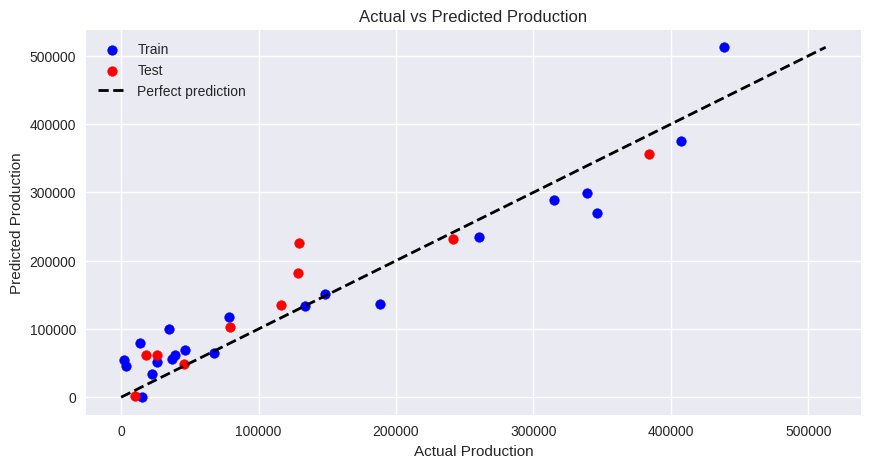

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.api as sm
import matplotlib.pyplot as plt

cols_production = ['large_residential', 'small_residential']
# cols_attraction = ['School', 'Health', 'Leisure',
#                        'Shops', 'Services', 'Industry', 'Catering_industry', 'Tourism',
#                        'Others', 'Leisure_area','total_residential']
cols_attraction = ['Leisure',
                       'Shops', 'Services',  'Catering_industry', 'Tourism',
                        'Leisure_area']


tmp_var = cols_attraction
response_variable = 'count_attr'   

X = analysis_df[tmp_var]
y = analysis_df[response_variable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LinearRegression(fit_intercept=False, positive=True)  # set positive=True if you want coeffs ≥0
model.fit(X_train, y_train)

print("Coefficients:")
for feature, coef in zip(tmp_var, model.coef_):
    print(f"  {feature}: {coef:.4f}")

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {train_r2:.3f}, MSE: {train_mse:.3f}")
print(f"Test R²: {test_r2:.3f}, MSE: {test_mse:.3f}")

# Plot actual vs predicted

plt.style.use('seaborn-v0_8')

plt.figure(figsize=(10,5))
plt.scatter(y_train, y_train_pred, color='blue', label='Train')
plt.scatter(y_test, y_test_pred, color='red', label='Test')
min_val = min(y.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y.max(), y_train_pred.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Production')
plt.ylabel('Predicted Production')
plt.title('Actual vs Predicted Production')
plt.legend()
plt.savefig("figures/calibration_fit_madrid")


In [29]:
len(X_train)

21